Trying to find a discriminator with parameters that achieve good loss

In [22]:
import argparse

def str_to_bool(value):
    """Convert argument string to boolean."""
    if isinstance(value, bool):
        return value
    if value.lower() in ('true', '1', 'yes', 'y'):
        return True
    elif value.lower() in ('false', '0', 'no', 'n'):
        return False
    else:
        raise argparse.ArgumentTypeError("Boolean value expected (true/false or 1/0).")
        
def int_or_str(val):
    try:
        return int(val)
    except ValueError:
        return val

parser = argparse.ArgumentParser()
parser.add_argument("--index", type=int_or_str, required=True, help="Filename index")
parser.add_argument("--discriminator_dropout_rate", type=float, required=True)
parser.add_argument("--discriminator_lambda_L2", type=float, required=True)
parser.add_argument("--n_layers_disc", type=int, required=True)
parser.add_argument("--epsilon_smooth", type=float, required=True)
parser.add_argument("--n_start_layers", type=int, required=True)


########################################################################
args = parser.parse_args()
fn = str(args.index)

discriminator_dropout_rate = args.discriminator_dropout_rate
discriminator_lambda_L2 = args.discriminator_lambda_L2
n_layers_disc = args.n_layers_disc
epsilon_smooth = args.epsilon_smooth
n_start_layers = args.n_start_layers




# python troubleshoot_discriminator.py --index 10 --discriminator_dropout_rate 0.1 --discriminator_lambda_L2 1e-4 --n_layers_disc 4 --epsilon_smooth 0.03448275862 --n_start_layers 0



In [2]:
# fn = '10'
# discriminator_dropout_rate = 0.1
# discriminator_lambda_L2 = 1e-4
# n_layers_disc = 4
# epsilon_smooth = 0.03448275862
# n_start_layers = 0

In [3]:
import os

import numpy as np
import torch
import torch.nn as nn

import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS.model.train import *

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
mod_seed = 888
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
author = 'Tahoe100M'

device = "cuda" if torch.cuda.is_available() else "cpu"


In [26]:
n_nodes = 863
drug_counts = 29

In [28]:
def generate_lr_params(n_epochs, 
                       max_lr, 
                       lr_scaling_factor=10, 
                       lr_decay=0.75,
                       n_restarts = 4,
                       n_discriminator_train=5, 
                       n_adversarial_start = 0,
                       role='scl'):

    total_active_epochs = n_epochs
    n_discriminator_train_ = 1
    if role in ['discriminator', 'generator']:
        total_active_epochs = n_epochs - n_adversarial_start
        if role == 'generator':
            n_discriminator_train_ = n_discriminator_train
            
#     n_restarts = 4 if total_active_epochs // n_discriminator_train_ > 500 else 2


    T_0 = max(1, (total_active_epochs // n_discriminator_train_) // n_restarts)
    warmup_epochs = max(1, (total_active_epochs // n_discriminator_train_) // 10)

#     if reset_state:
#         if total_active_epochs // n_discriminator_train_ > 400:
#             n_optimizer_resets = 2
#         elif total_active_epochs // n_discriminator_train_ < 100:
#             n_optimizer_resets = 0
#         else:
#             n_optimizer_resets = 1
#     else:
#         n_optimizer_resets = 0
        
    if warmup_epochs >= T_0:
        warmup_epochs = 0

    return {
        'max_epochs': n_epochs,
        'maximum_learning_rate': max_lr,
        'minimum_learning_rate': max_lr / lr_scaling_factor,
        'lr_restart_epoch': T_0,  
        'n_optimizer_resets': 0,  # no longer used
        'lr_decay': lr_decay,
        'lr_restart_factor': 1,
        'warmup_epochs': warmup_epochs
    }

In [29]:
max_epochs = 600
max_lr = 0.001
lr_scaling_factor = 10
lr_decay = 0.75

n_adversarial_start = 0
n_restarts_adversarial = 4
n_discriminator_train = 5

discriminator_params = {
    'batch_momentum': None,
    'layer_norm': False,
    'spectral_norm': False,
    'dropout_rate': discriminator_dropout_rate,
    'activation_fn': nn.LeakyReLU,
    'n_hidden_nodes': np.nan,
    'lr_restart_factor': 1,
    'optimizer': torch.optim.Adam,
    'discriminator_lambda_L2': discriminator_lambda_L2,
    'discriminator_penalty_weight': np.nan, 
    'bionet_activation': False,
    'smooth_labels': True, 
    'epsilon_smooth': np.nan
}



discriminator_lr_params = generate_lr_params(
    n_epochs = max_epochs,
    max_lr = max_lr,
    lr_scaling_factor = lr_scaling_factor, 
    lr_decay = lr_decay,
    n_restarts = n_restarts_adversarial,
    n_adversarial_start = n_adversarial_start, 
    n_discriminator_train = n_discriminator_train,
    role = 'discriminator')
del discriminator_lr_params['max_epochs']

discriminator_params = {**discriminator_params, **discriminator_lr_params}



In [30]:
pert_disc_n_hidden_nodes = list(np.round(np.linspace(n_nodes, 
                                                     drug_counts, 
                                                     n_layers_disc + 2)).astype(int)[1:-1])
pert_disc_n_hidden_nodes = [pert_disc_n_hidden_nodes[0]]*n_start_layers + pert_disc_n_hidden_nodes



discriminator_params['n_hidden_nodes'] = pert_disc_n_hidden_nodes


discriminator_params['epsilon_smooth'] = epsilon_smooth

pert_discriminator_params = discriminator_params

In [31]:
fn_ = 'no_pert_adv_'
trainer = io.read_pickled_object(os.path.join(data_path, 'trash', fn_ + author +  '_trainer.pickle'))
mod = trainer.mod
freeze_model(mod)
mod.eval()

SignalingModel(
  (input_layer): ProjectInput()
  (signaling_network): BioNetSC(
    (cat_embeddings): ModuleDict(
      (cell_line): Embedding(10, 863, max_norm=100)
    )
    (vae): GaussianVariationalEncoder(
      (hidden_layers): FCLayers(
        (fc_layers): Sequential(
          (FC Layer 0): Sequential(
            (linear): Linear(in_features=3000, out_features=1932, bias=True)
            (batch normalization): BatchNorm1d(1932, eps=1e-05, momentum=0.01, affine=True, track_running_stats=True)
            (activation): LeakyReLU(negative_slope=0.01)
            (dropout): Dropout(p=0.7, inplace=False)
          )
        )
      )
      (z_mean): Linear(in_features=1932, out_features=863, bias=True)
      (z_log_var): Linear(in_features=1932, out_features=863, bias=True)
    )
  )
  (output_layer): ProjectOutput()
)

Initialize:

In [32]:
pert_discriminator = {}
pert_discriminator['params'] = update_with_defaults(trainer.PERT_DISCRIMINATOR_PARAMS, pert_discriminator_params)
pert_discriminator['params']['reset_optimizer_epoch'] = max_epochs + 1

discriminator = CatDiscriminator(n_features_in = n_nodes,
                  n_labels = drug_counts,
                  dtype = mod.dtype, 
                  device = mod.device,
                 batch_momentum = pert_discriminator['params']['batch_momentum'], 
                 layer_norm = pert_discriminator['params']['layer_norm'],
                 spectral_norm = pert_discriminator['params']['spectral_norm'],
                 dropout_rate = pert_discriminator['params']['dropout_rate'], 
                 activation_fn = pert_discriminator['params']['activation_fn'], 
                 bionet_activation = pert_discriminator['params']['bionet_activation'], 
                 rnn_params = {'activation_function': mod.signaling_network.activation_function, 
                               'leak': mod.signaling_network.bionet_params['leak']},
                 smooth_labels = pert_discriminator['params']['smooth_labels'],
                 epsilon_smooth = pert_discriminator['params']['epsilon_smooth'],                                
                 n_hidden_nodes = pert_discriminator['params']['n_hidden_nodes'], 
                 seed = trainer.train_seed)

optimizer = pert_discriminator['params']['optimizer'](discriminator.parameters(),
                                          lr = pert_discriminator['params']['maximum_learning_rate'],
                                          weight_decay = 0)

lr_scheduler = WarmupCosineAnnealingWarmRestarts(optimizer = optimizer,
                                                 T_0 = pert_discriminator['params']['lr_restart_epoch'],
                                                      T_mul = pert_discriminator['params']['lr_restart_factor'], 
                                                      gamma = pert_discriminator['params']['lr_decay'],
                                                      eta_min = pert_discriminator['params']['minimum_learning_rate'],
                                                      max_lr=pert_discriminator['params']['maximum_learning_rate'],
                                                      warmup_steps = pert_discriminator['params']['warmup_epochs'],
                                                      last_epoch = -1)



Train:

In [9]:
stats_cols = ['epoch', 'batch', 'lr', 'prediction', 'L2_reg', 'total']
stats = np.empty((0, len(stats_cols)))
for e in trange(max_epochs):
    pert_discriminator['_cur_lr'] = optimizer.param_groups[0]['lr']
    utils.set_seeds(mod.seed + e)
    for batch, (X_in_, y_out_, covariates_idx_, expr_) in enumerate(trainer.train_dataloader):
        X_in_, y_out_, covariates_idx_, expr_ = X_in_.to(device), y_out_.to(device), covariates_idx_.to(device), expr_.to(device)

        _, _, biases = mod(X_in_, covariates_idx_, expr_)
        bias_global, _, _ = biases
        
                
        discriminator.train()
        optimizer.zero_grad()
        
        bias_global_prediction = discriminator(bias_global.detach()) # predicted logits

        target = X_in_.argmax(dim=1)
        no_pert = X_in_.sum(dim=1) == 0  
        target[no_pert] = discriminator.n_labels - 1 # -1 for indexing
        
        pert_discriminator_loss_accuracy = discriminator.loss_fn(bias_global_prediction, target)   
        pert_discriminator_reg = discriminator.L2_reg(pert_discriminator['params']['discriminator_lambda_L2'])

        pert_discriminator_loss = pert_discriminator_loss_accuracy + pert_discriminator_reg

        pert_discriminator_loss.backward() 
        
        optimizer.step()
        
        sv = np.array([e, batch, pert_discriminator['_cur_lr'],
               pert_discriminator_loss_accuracy.item(), pert_discriminator_reg.item(), pert_discriminator_loss.item()])
        stats = np.vstack((stats, sv)) 
        
        del biases, y_out_, covariates_idx_, expr_, X_in_
                                                                                   
    lr_scheduler.step()
    utils.clear_memory()

stats = pd.DataFrame(stats, columns = stats_cols)
stats.to_csv(os.path.join(data_path, 'trash', fn + '_' + author + '_discriminator_stats.csv'))


100%|█████████████████████████████████████| 2/2 [00:04<00:00,  2.03s/it]


In [105]:
for fn in [f for f in os.listdir(os.curdir) if f.endswith('.slurm')]:
    print('sbatch ' + fn)
    print()

sbatch batch_job1.slurm

sbatch batch_job1-Copy2.slurm

sbatch batch_job1-Copy1.slurm



In [5]:
files = [f for f in os.listdir(os.path.join(data_path, 'trash')) if f.endswith(author + '_discriminator_stats.csv')]

files = sorted([f for f in files if not f.startswith('no_pert_adv')])

include = ['11', '12', '13', '14']

files = [f for f in files if f.split('_')[0] in include]

In [6]:
files

['11_Tahoe100M_discriminator_stats.csv',
 '12_Tahoe100M_discriminator_stats.csv',
 '13_Tahoe100M_discriminator_stats.csv',
 '14_Tahoe100M_discriminator_stats.csv']

In [8]:
f = '12_Tahoe100M_discriminator_stats.csv'

stats = pd.read_csv(os.path.join(data_path, 'trash', f), index_col=0)
stats = stats.groupby('epoch').mean().reset_index().drop(columns=['batch', 'lr'])

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

tf_adata = io.read_tfad(os.path.join(data_path, 'processed', author + '_consensus_tf_activity.h5ad'))

trainer = io.read_pickled_object(os.path.join(data_path, 'trash', fn_ + author +  '_trainer.pickle'))
train_cells = trainer.X_train.index.tolist()


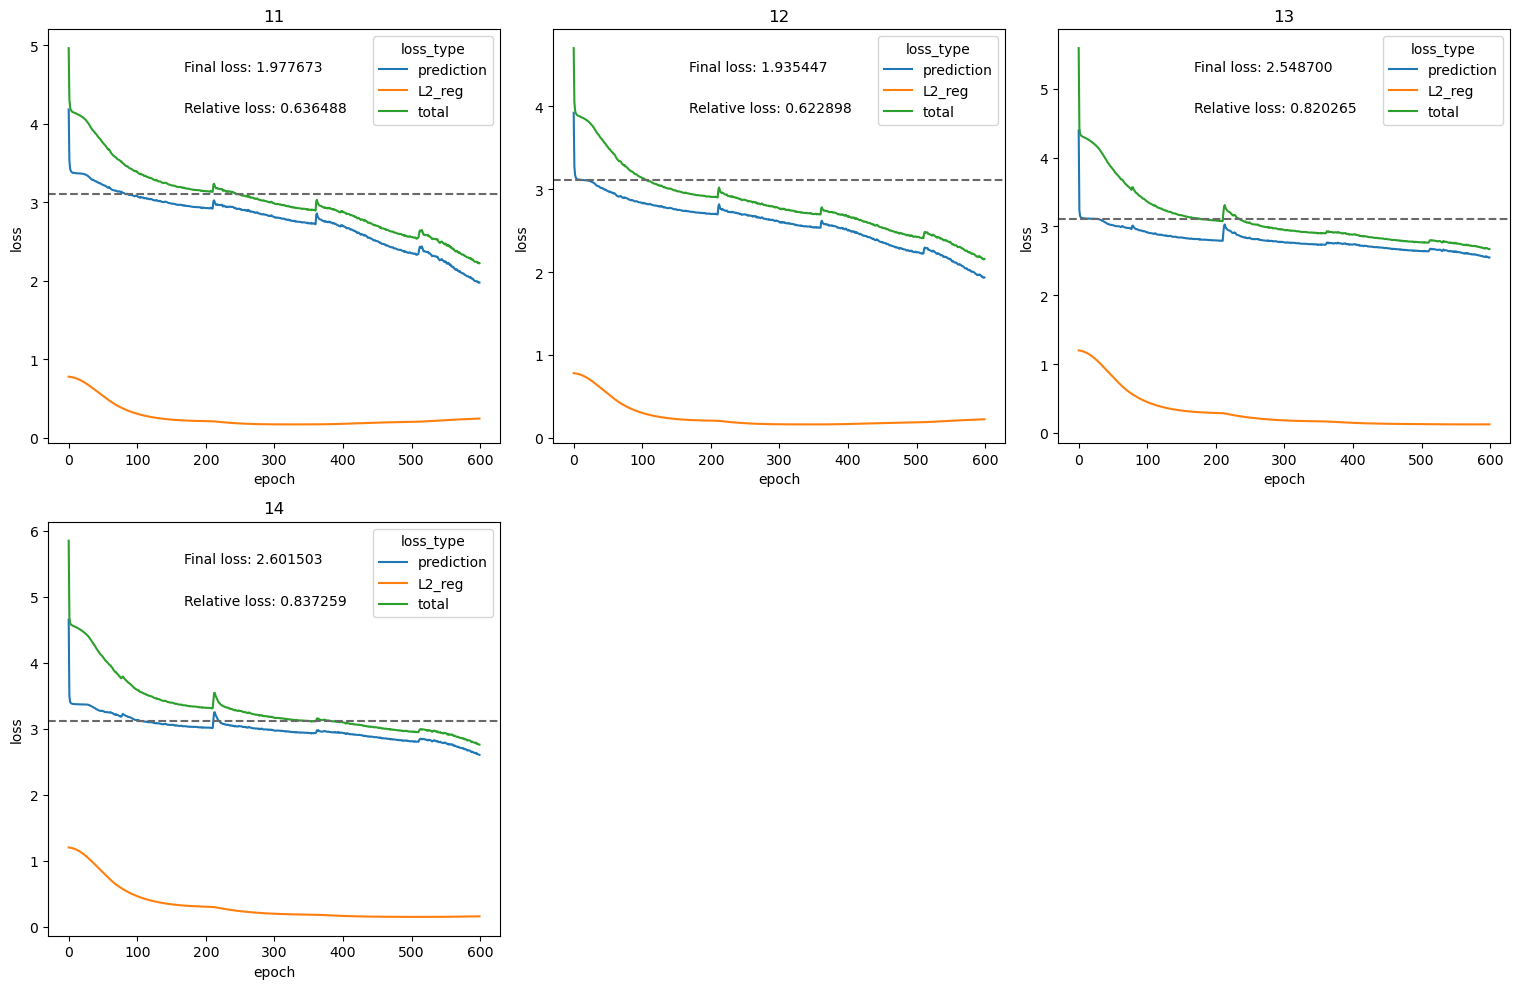

In [109]:
n_cols = min(len(files), 3)
n_rows = math.ceil(len(files) / n_cols)

fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(5.1 * n_cols, 5 * n_rows))
ax = ax.flatten()  # Flatten for easier indexing

cp = tf_adata[train_cells, :].obs.drug.value_counts(normalize=True).values
rand_loss = trainer.pert_discriminator['discriminator'].random_loss(class_probs=cp)

for i, f in enumerate(files):
    index = int(f.split('_')[0])
    stats = pd.read_csv(os.path.join(data_path, 'trash', f), index_col=0)
    stats = stats.groupby('epoch').mean().reset_index().drop(columns=['batch', 'lr'])
    viz_df = pd.melt(stats, id_vars='epoch', var_name='loss_type', value_name='loss')

    sns.lineplot(data=viz_df, x='epoch', y='loss', hue='loss_type', ax=ax[i])
    ax[i].set_title(index)
    ax[i].axhline(y=rand_loss, color='dimgray', linestyle='--')

    final_loss = stats.prediction.tolist()[-1]
    ax[i].annotate('Final loss: {:4f}'.format(final_loss),
                   xy=(0.3, 0.9),
                   xycoords='axes fraction')
    ax[i].annotate('Relative loss: {:4f}'.format(final_loss / rand_loss),
                   xy=(0.3, 0.8),
                   xycoords='axes fraction')

# Hide unused subplots if any
for j in range(len(files), len(ax)):
    fig.delaxes(ax[j])

fig.tight_layout()